# DBSCAN Clustering

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
import time  # Added for execution time tracking

In [2]:
# Load the dataset
X = pd.read_csv('finalclusteringdataset.csv')
start_time = time.time()  # Start timing

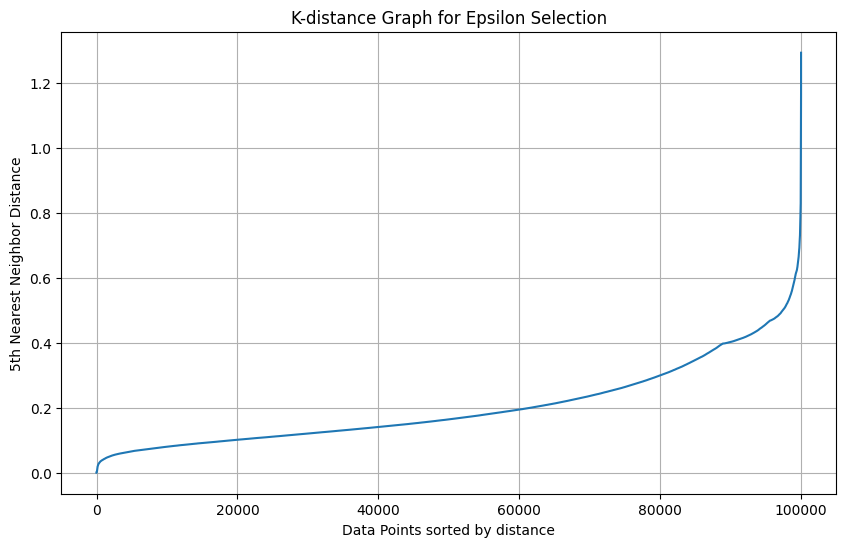

In [3]:
# Find optimal epsilon using k-distance graph
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)
distances = np.sort(distances[:, -1], axis=0)

# Plot k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Data Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.title('K-distance Graph for Epsilon Selection')
plt.grid(True)
plt.show()

In [4]:
# AUTOMATIC EPSILON SELECTION - using percentile method
eps_min = distances[int(len(distances)*0.95)]
eps_max = distances[int(len(distances)*0.99)]
eps_auto = (eps_min + eps_max) / 2  # Take midpoint

print(f'Suggested epsilon range: {eps_min:.4f} to {eps_max:.4f}')
print(f'Auto-selected epsilon: {eps_auto:.4f}')

Suggested epsilon range: 0.4568 to 0.5847
Auto-selected epsilon: 0.5208


In [5]:
# Apply DBSCAN with AUTO epsilon
min_samples = 5  # Adjust if needed
dbscan = DBSCAN(eps=eps_auto, min_samples=min_samples, algorithm='auto')
cluster_labels = dbscan.fit_predict(X)
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)

In [6]:
# Evaluate clustering (only if we have at least 2 clusters and not all noise)
if n_clusters > 1 and n_noise < len(X):
    mask = cluster_labels != -1
    if mask.sum() > 0:
        sample_idx = np.random.choice(mask.sum(), size=min(10000, mask.sum()), replace=False)
        sil_score = silhouette_score(X[mask].iloc[sample_idx], cluster_labels[mask][sample_idx])
        db_score = davies_bouldin_score(X[mask], cluster_labels[mask])
    else:
        sil_score = None
        db_score = None
else:
    sil_score = None
    db_score = None

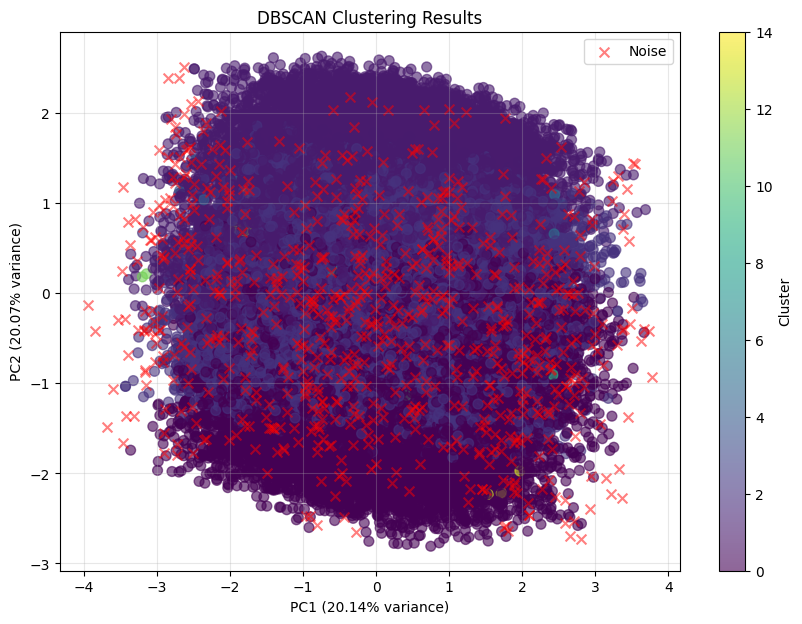

In [7]:
# Visualize clusters (2D projection)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
# Use noise_mask to highlight noise points differently
noise_mask = cluster_labels == -1
scatter = plt.scatter(X_pca[~noise_mask, 0], X_pca[~noise_mask, 1], 
                     c=cluster_labels[~noise_mask], cmap='viridis', s=50, alpha=0.6)
plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], 
           c='red', marker='x', s=50, alpha=0.5, label='Noise')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('DBSCAN Clustering Results')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# Cluster distribution
unique, counts = np.unique(cluster_labels, return_counts=True)

In [9]:
# Calculate metrics before saving
end_time = time.time()
execution_time = end_time - start_time
# Print summary metrics
print(f'Number of Clusters: {n_clusters}')
if sil_score is not None:
    print(f'Silhouette Score: {sil_score:.4f}')
    print(f'Davies-Bouldin Score: {db_score:.4f}')
else:
    print('Silhouette Score: N/A')
    print('Davies-Bouldin Score: N/A')
for cluster, count in zip(unique, counts):
    if cluster == -1:
        print(f'Noise Points: {count} samples ({count/len(X)*100:.2f}%)')
    else:
        print(f'Cluster {cluster}: {count} samples ({count/len(X)*100:.2f}%)')
print(f'Execution Time: {execution_time:.2f} seconds')
# Save results
X['Cluster'] = cluster_labels
X.to_csv('dbscan_results.csv', index=False)

Number of Clusters: 15
Silhouette Score: -0.0116
Davies-Bouldin Score: 1.1397
Noise Points: 740 samples (0.74%)
Cluster 0: 32797 samples (32.80%)
Cluster 1: 33238 samples (33.24%)
Cluster 2: 33174 samples (33.17%)
Cluster 3: 2 samples (0.00%)
Cluster 4: 7 samples (0.01%)
Cluster 5: 5 samples (0.00%)
Cluster 6: 5 samples (0.00%)
Cluster 7: 5 samples (0.00%)
Cluster 8: 4 samples (0.00%)
Cluster 9: 4 samples (0.00%)
Cluster 10: 7 samples (0.01%)
Cluster 11: 2 samples (0.00%)
Cluster 12: 5 samples (0.00%)
Cluster 13: 5 samples (0.00%)
Cluster 14: 2 samples (0.00%)
Execution Time: 8.30 seconds
